### 1. Import libraries

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### 2. Load Data

In [2]:
# Load dataset
df = pd.read_excel("flight-fare\Flight_Fare.xlsx")

# Show first 5 rows
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### 3. Basic Inspection

In [3]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Dataset information
df.info()

# Check null values
df.isnull().sum()

Shape of dataset: (10683, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Insight: 'Route' and 'Total_Stops' has 1 missing value

### 4. Understanding the Dataset properly

In [4]:
# Column names
print(df.columns)

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')


In [5]:
# Statistical summary
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [6]:
# Check unique values in each column
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

Airline : 12
Date_of_Journey : 44
Source : 5
Destination : 6
Route : 128
Dep_Time : 222
Arrival_Time : 1343
Duration : 368
Total_Stops : 5
Additional_Info : 10
Price : 1870


### 5. Handle Missing values

In [7]:
# Since there is only one single row is missing, we are going to remove that row entirely
# Check null rows
df[df.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [8]:
# Drop missing values
df.dropna(inplace=True)

# Verify null values again
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

### 6. Check Duplicate rows

In [9]:
# Check duplicate rows
df.duplicated().sum()

220

In [10]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Check shape after removing duplicates
df.shape

(10462, 11)

## Feature Engineering

### 7. Process Date_of_Journey

In [11]:
# Extract Journey Day
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day

# Extract Journey Month
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

# Drop original column
df.drop("Date_of_Journey", axis=1, inplace=True)

#Check dataset
df.head(5)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


### 8. Process Departure Time

In [12]:
# Extract departure hour
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

# Extract departure minute
df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

# Drop original column
df.drop("Dep_Time", axis=1, inplace=True)

df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


### 9. Process Arrival Time

In [13]:
# Extract Arrival Hour
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

# Extract Arrival Minute
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

# Drop original column
df.drop("Arrival_Time", axis=1, inplace=True)

df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


We do these all because flight prices depend heavily on:

Morning/night flights

Weekend/month demand

Peak travel periods

Flight timing

### 10. Convert Duration Properly

In [14]:
# Convert Duration column into list
duration = list(df["Duration"])

In [15]:
# Handle cases where duration has only hour or only minute

for i in range(len(duration)):
    
    if len(duration[i].split()) != 2: 
        
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
            
        else:
            duration[i] = "0h " + duration[i]

### 11. Extract Duration Hours & Minutes

In [16]:
# Empty lists
duration_hours = []
duration_mins = []

# Extract hours and minutes
for i in range(len(duration)):
    
    duration_hours.append(int(duration[i].split(sep="h")[0]))
    
    duration_mins.append(int(duration[i].split(sep="m")[0].split()[-1]))

### 12. Add new Columns

In [17]:
# Add duration columns
df["Duration_hours"] = duration_hours
df["Duration_mins"] = duration_mins

# Drop original Duration column
df.drop("Duration", axis=1, inplace=True)

# Check dataframe
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


### 13. Explore Categorical Columns

In [18]:
# Check categorical columns
categorical_cols = ["Airline", "Source", "Destination", "Total_Stops", "Additional_Info"]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Airline
Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

Source
Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

Destination
Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

Total_Stops
Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

Additional_Info
Additional_Info

### 14. Handle Total_Stops

In [19]:
# Mapping Total_Stops
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,16,50,21,35,4,45


### 15. One Hot Encoding for Airline

In [20]:
# One Hot Encoding for Airline
airline = pd.get_dummies(df["Airline"], drop_first=True)

airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


### 16. One Hot Encoding for Source

In [21]:
# One Hot Encoding for Source
source = pd.get_dummies(df["Source"], drop_first=True)

source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


### 17. One Hot Encoding for Destination

In [22]:
# One Hot Encoding for Destination
destination = pd.get_dummies(df["Destination"], drop_first=True)

destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


### 18. Drop Unnecessary Columns

In [23]:
# Drop unnecessary columns
df.drop(["Airline", "Source", "Destination", "Route", "Additional_Info"], axis=1, inplace=True)

df.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,0,3897,24,3,22,20,1,10,2,50
1,2,7662,1,5,5,50,13,15,7,25
2,2,13882,9,6,9,25,4,25,19,0
3,1,6218,12,5,18,5,23,30,5,25
4,1,13302,1,3,16,50,21,35,4,45


Why dropped Route? Route has 128 unique values, That creates:

too many sparse columns,
 high dimensionality,
 risk of overfitting

Also:

Total_Stops already captures much route complexity

So dropping Route is a smart modeling choice.

### 19. Combine Encoded Columns

In [24]:
# Concatenate dataframe
final_df = pd.concat([df, airline, source, destination], axis=1)

final_df.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,False,False,False,False,False,False,False,False,False,True
1,2,7662,1,5,5,50,13,15,7,25,...,False,False,False,True,False,False,False,False,False,False
2,2,13882,9,6,9,25,4,25,19,0,...,False,False,True,False,False,True,False,False,False,False
3,1,6218,12,5,18,5,23,30,5,25,...,False,False,False,True,False,False,False,False,False,False
4,1,13302,1,3,16,50,21,35,4,45,...,False,False,False,False,False,False,False,False,False,True


### 20. Check Final Dataset

In [25]:
final_df.shape

(10462, 30)

In [26]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Total_Stops                        10462 non-null  int64
 1   Price                              10462 non-null  int64
 2   Journey_day                        10462 non-null  int32
 3   Journey_month                      10462 non-null  int32
 4   Dep_hour                           10462 non-null  int32
 5   Dep_min                            10462 non-null  int32
 6   Arrival_hour                       10462 non-null  int32
 7   Arrival_min                        10462 non-null  int32
 8   Duration_hours                     10462 non-null  int64
 9   Duration_mins                      10462 non-null  int64
 10  Air India                          10462 non-null  bool 
 11  GoAir                              10462 non-null  bool 
 12  IndiGo                 

Insight: There are duplicate columns, two Delhi and Kolkata columns.

### 21. Fix Duplicate Column Names

In [27]:
# Rename source columns
source = source.add_prefix("Source_")

source.head()

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


In [28]:
# Rename destination columns
destination = destination.add_prefix("Destination_")

destination.head()

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [29]:
# Recreate final dataframe
final_df = pd.concat([df, airline, source, destination], axis=1)

final_df.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,...,Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,False,False,False,False,False,False,False,False,False,True
1,2,7662,1,5,5,50,13,15,7,25,...,False,False,False,True,False,False,False,False,False,False
2,2,13882,9,6,9,25,4,25,19,0,...,False,False,True,False,False,True,False,False,False,False
3,1,6218,12,5,18,5,23,30,5,25,...,False,False,False,True,False,False,False,False,False,False
4,1,13302,1,3,16,50,21,35,4,45,...,False,False,False,False,False,False,False,False,False,True


In [30]:
# Verify columns
final_df.columns

Index(['Total_Stops', 'Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_min', 'Arrival_hour', 'Arrival_min', 'Duration_hours',
       'Duration_mins', 'Air India', 'GoAir', 'IndiGo', 'Jet Airways',
       'Jet Airways Business', 'Multiple carriers',
       'Multiple carriers Premium economy', 'SpiceJet', 'Trujet', 'Vistara',
       'Vistara Premium economy', 'Source_Chennai', 'Source_Delhi',
       'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi'],
      dtype='object')

Insight: We removed all duplicate columns and added source and destination. 

## EDA (Exploratory Data Analysis)

### 22. Correlation Heatmap

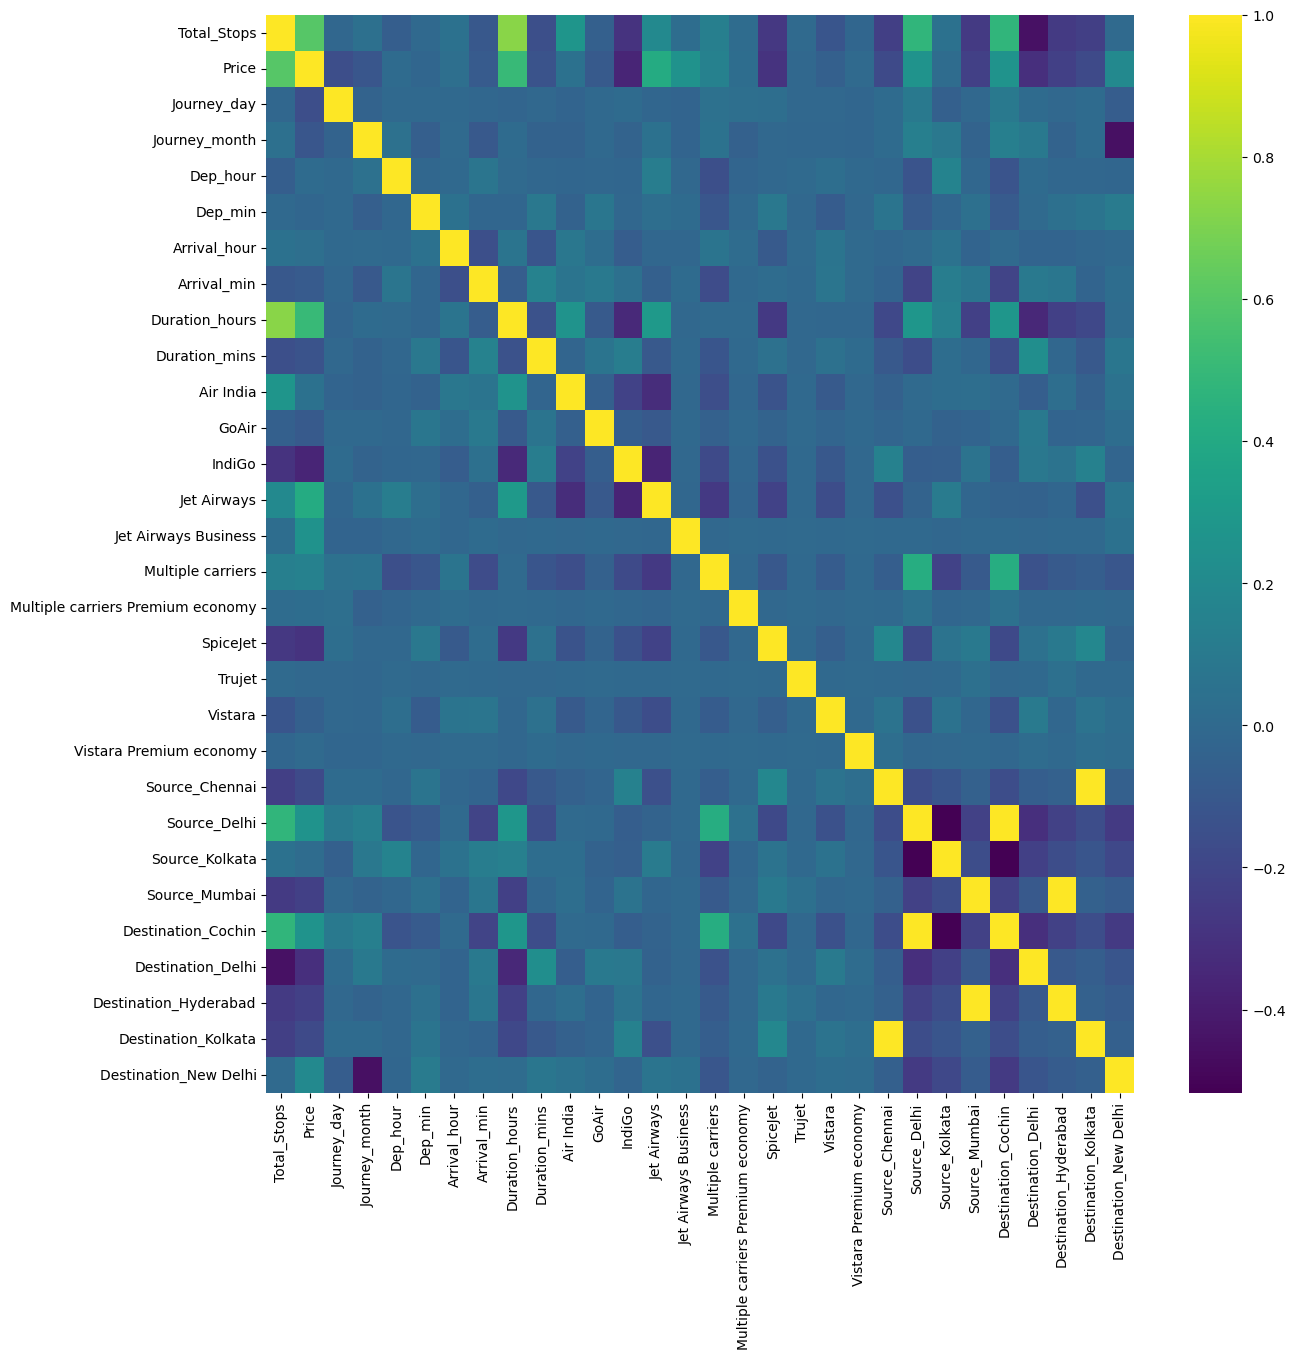

In [31]:
# Correlation matrix
plt.figure(figsize=(14,14))

sns.heatmap(final_df.corr(), annot=False, cmap="viridis")

plt.show()

### 23. Check Price Distribution

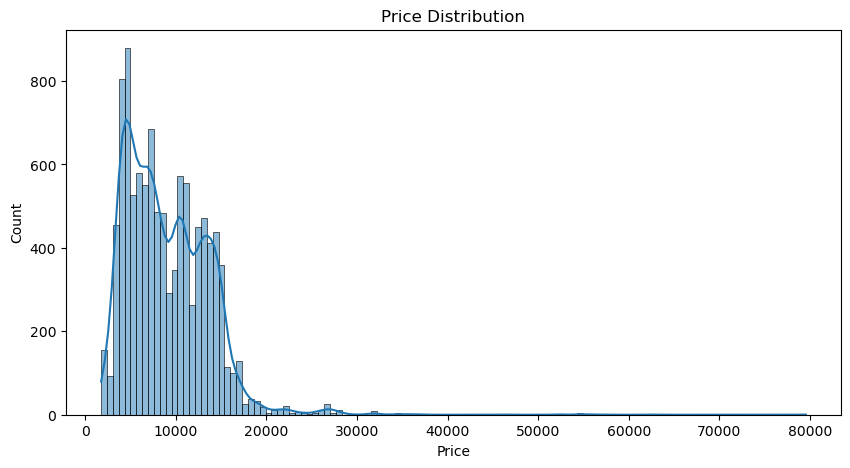

In [32]:
# Distribution of Price
plt.figure(figsize=(10,5))

sns.histplot(final_df["Price"], kde=True)

plt.title("Price Distribution")

plt.show()

### 24. Airline vs Price

In [33]:
# Reload original dataset for visualization
eda_df = pd.read_excel("flight-fare\Flight_Fare.xlsx")

# Remove null values
eda_df.dropna(inplace=True)

# Remove duplicates
eda_df.drop_duplicates(inplace=True)

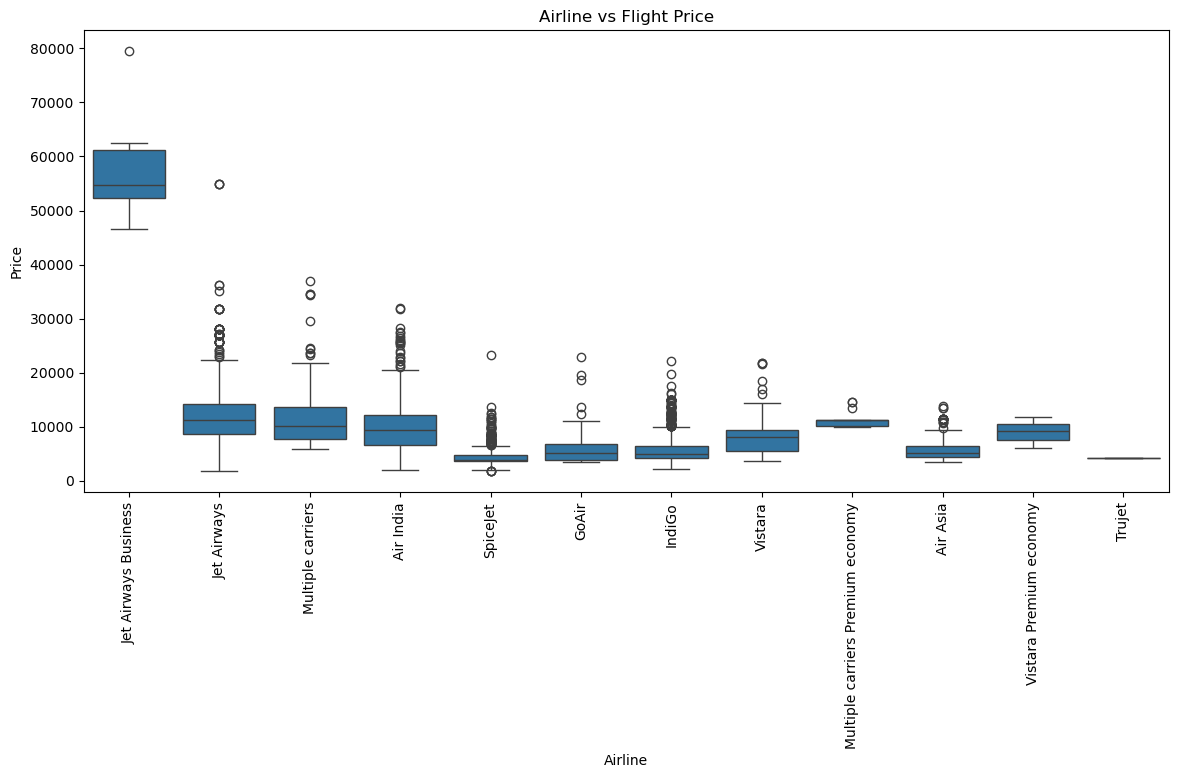

In [34]:
# Now create boxplot 
plt.figure(figsize=(14,6))

sns.boxplot(x="Airline", y="Price", data=eda_df.sort_values("Price", ascending=False))

plt.xticks(rotation=90)

plt.title("Airline vs Flight Price")

plt.show()

Insight: The airline feature significantly impacts flight prices. Premium airlines like Jet Airways Business have much higher median fares, while budget airlines such as SpiceJet and Air Asia show lower fare distributions. Several airlines also exhibit large price variability and outliers, indicating dynamic pricing behavior.

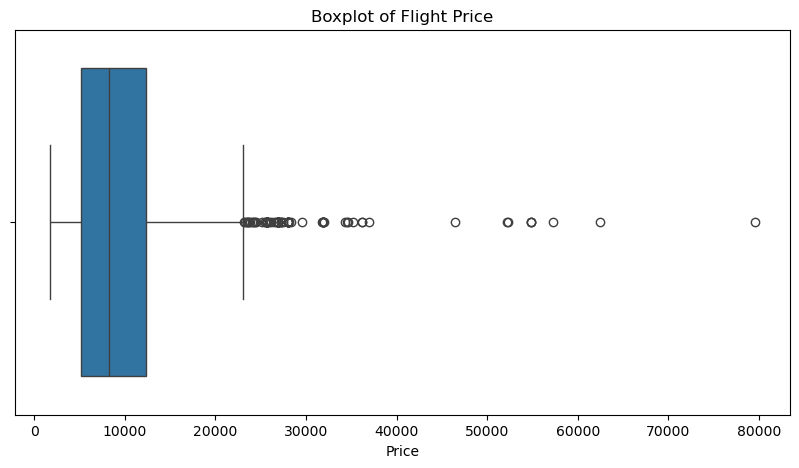

In [35]:
# Boxplot for Price
plt.figure(figsize=(10,5))

sns.boxplot(x=eda_df["Price"])

plt.title("Boxplot of Flight Price")

plt.show()

In [36]:
# Check skewness
eda_df["Price"].skew()

1.8574899082173875

## Machine Learning

### 25. Split Features and Target

In [37]:
# Independent features
X = final_df.drop("Price", axis=1)

# Target feature
y = final_df["Price"]

### 26. Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8369, 29)
X_test shape: (2093, 29)
y_train shape: (8369,)
y_test shape: (2093,)


### 27. Import Models & Metrics

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 28. Train Random Forest Model

In [41]:
# Create model
rf_model = RandomForestRegressor()

# Train model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### 29. Predictions

In [42]:
# Predictions
y_pred = rf_model.predict(X_test)

### 30. Evaluate Model

In [43]:
# Evaluation metrics

print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1178.7701179028013
MSE: 3934098.562422772
RMSE: 1983.45621641184
R2 Score: 0.8113167187274709


### 31. Feature Importance

In [44]:
# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_})

# Sort values
importance = importance.sort_values(
    by="Importance",
    ascending=False)

importance.head(10)

,Feature,Importance
7,Duration_hours,0.440215
1,Journey_day,0.128370
13,Jet Airways Business,0.071394
12,Jet Airways,0.064579
2,Journey_month,0.062465
5,Arrival_hour,0.031371
0,Total_Stops,0.031124
3,Dep_hour,0.027748
4,Dep_min,0.023532
14,Multiple carriers,0.020572


### 32. Visualize top features

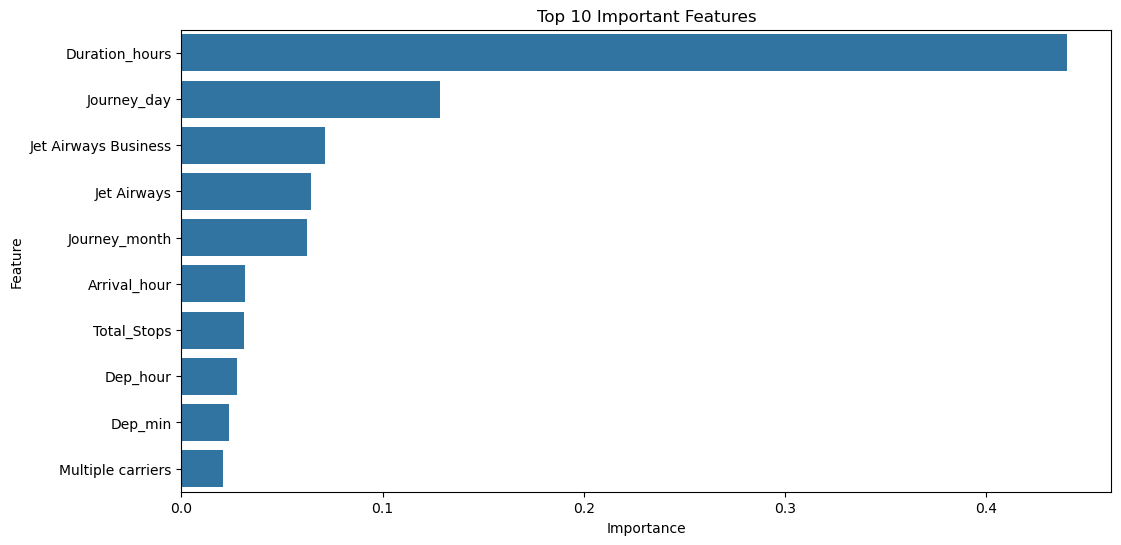

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

### 33. Actual vs Predicted Plot

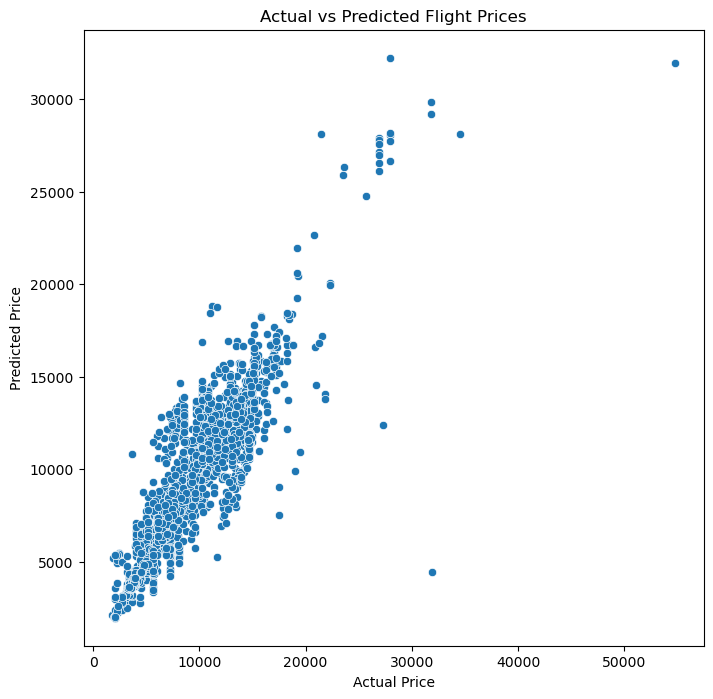

In [46]:
plt.figure(figsize=(8,8))

sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Flight Prices")

plt.show()

### 34. Residual Distribution

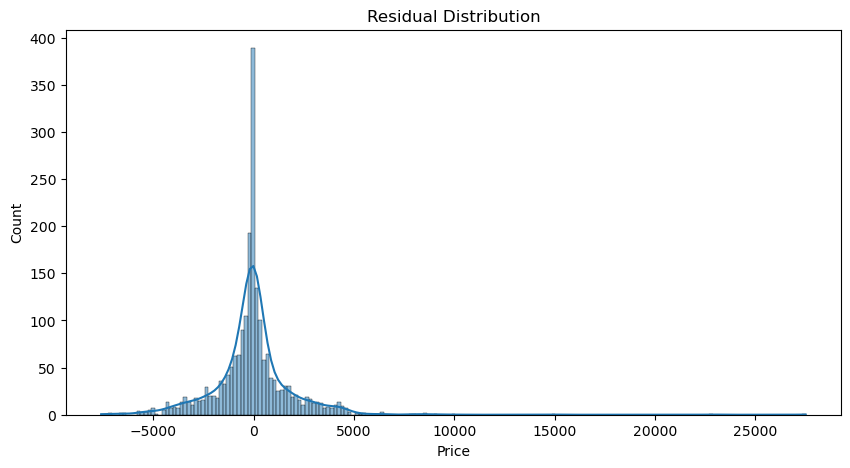

In [47]:
# Residuals
residuals = y_test - y_pred

plt.figure(figsize=(10,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

### 35. Hyperparameter Tuning

In [48]:
from sklearn.model_selection import RandomizedSearchCV

### 36. Create Parameter Grid

In [49]:
# Parameters
param_grid = {
    
    "n_estimators": [100, 120, 150],
    
    "max_depth": [10, 15, 20, None],
    
    "min_samples_split": [2, 5, 10],
    
    "min_samples_leaf": [1, 2, 4]
}

### 37. RandomizedSearchCV

In [50]:
# Create Random Forest
rf = RandomForestRegressor()

# Random search
random_search = RandomizedSearchCV(
    
    estimator=rf,
    
    param_distributions=param_grid,
    
    n_iter=10,
    
    scoring="r2",
    
    cv=3,
    
    verbose=2,
    
    random_state=42,
    
    n_jobs=-1
)

### 38. Train Search Model

In [51]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 120, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

### 39. Best Parameters

In [52]:
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': 15}

In [53]:
random_search.best_score_

0.8124251319330181

### 40. Evaluate Tuned Model

In [54]:
# Best model
best_rf = random_search.best_estimator_

# Predictions
y_pred_tuned = best_rf.predict(X_test)

# Metrics
print("R2 Score:", r2_score(y_test, y_pred_tuned))

print("MAE:", mean_absolute_error(y_test, y_pred_tuned))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))

R2 Score: 0.8354740570404844
MAE: 1136.2702073737498
RMSE: 1852.1369771271823


### 41. Train ExtraTreesRegressor

In [55]:
from sklearn.ensemble import ExtraTreesRegressor

In [56]:
# Create model
et_model = ExtraTreesRegressor()

# Train model
et_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

### 42. Predictions

In [57]:
# Predictions
y_pred_et = et_model.predict(X_test)

### 43. Evaluate Extra Trees Model

In [58]:
print("R2 Score:", r2_score(y_test, y_pred_et))

print("MAE:", mean_absolute_error(y_test, y_pred_et))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_et)))

R2 Score: 0.7806358661969505
MAE: 1224.94343964007
RMSE: 2138.6450891145914


### 44. Feature Importance (Extra Trees)

In [59]:
# Feature importance
et_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": et_model.feature_importances_
})

et_importance = et_importance.sort_values(
    by="Importance",
    ascending=False
)

et_importance.head(10)

,Feature,Importance
0,Total_Stops,0.278705
1,Journey_day,0.137481
12,Jet Airways,0.127763
7,Duration_hours,0.095852
13,Jet Airways Business,0.081492
2,Journey_month,0.050913
5,Arrival_hour,0.026952
3,Dep_hour,0.025218
11,IndiGo,0.022773
28,Destination_New Delhi,0.022103


More advanced models are not always better.

### Final Model Comparison Table

In [60]:
# Model comparison table

comparison = pd.DataFrame({
    
    "Model": [
        "Random Forest",
        "Tuned Random Forest",
        "Extra Trees Regressor"
    ],
    
    "R2 Score": [
        0.8118,
        0.8349,
        0.7798
    ],
    
    "RMSE": [
        1980,
        1855,
        2142
    ],
    
    "MAE": [
        1182,
        1140,
        1229
    ]
})

comparison

,Model,R2 Score,RMSE,MAE
0,Random Forest,0.8118,1980,1182
1,Tuned Random Forest,0.8349,1855,1140
2,Extra Trees Regressor,0.7798,2142,1229


# Business Insights:

## 1. Flight Duration Strongly Affects Ticket Price
Flight duration was identified as the most important feature influencing airfare prices. Longer flights generally tend to have higher ticket prices due to increased operational and fuel costs.

---

## 2. Airline Type Has Major Impact on Fare
Premium airlines such as **Jet Airways Business** and **Jet Airways** showed significantly higher ticket prices compared to budget airlines like **SpiceJet**, **Air Asia**, and **GoAir**.

---

## 3. Journey Date Influences Pricing
The day and month of journey significantly affected flight prices. This indicates that airfare changes depending on seasonal demand, holidays, weekends, and travel trends.

---

## 4. Number of Stops Affects Fare Patterns
Flights with multiple stops showed different pricing behavior compared to non-stop flights. Total stops also contributed significantly to flight duration and overall pricing.

---

## 5. Flight Prices Are Highly Dynamic
The dataset contained several high-price outliers, showing that airline ticket prices fluctuate heavily based on factors such as booking demand, airline category, and travel timing.

# Challenges Faced:

## 1. Handling Missing Values
The dataset contained missing values in the `Route` and `Total_Stops` columns. Since only one row was affected, the row was safely removed without impacting the dataset significantly.

---

## 2. Processing Time-Based Features
Columns such as `Date_of_Journey`, `Dep_Time`, `Arrival_Time`, and `Duration` were initially stored as text values. Feature engineering techniques were applied to extract meaningful numerical features like hours, minutes, journey day, and journey month.

---

## 3. Encoding Categorical Variables
Several categorical columns such as `Airline`, `Source`, and `Destination` needed to be converted into numerical form using One Hot Encoding. The `Total_Stops` column was mapped into ordered numerical values.

---

## 4. Managing High Cardinality Features
The `Route` column contained a large number of unique values, which could increase model complexity and dimensionality. Therefore, the feature was dropped during preprocessing.

---

## 5. Handling Skewed Data and Outliers
The target variable `Price` showed high positive skewness and contained several outliers. These outliers were retained because they represented realistic airline pricing scenarios and premium ticket categories.

---

## 6. Model Optimization
Different regression models were compared to identify the best-performing algorithm. Hyperparameter tuning using `RandomizedSearchCV` significantly improved the performance of the Random Forest Regressor model.

## Save the Model

In [61]:
import joblib

# Save the best model
joblib.dump(best_rf, "flight_price_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
